In [1]:
#Import Libraries
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Load Dataset
df=pd.read_csv('/Users/shubhamkumar/Downloads/preprocessed (1).csv')

In [3]:
df.head()

,Planet_Name,Planet_Radius,Planet_Mass,Orbital_Period,Semi_Major_Axis,Equilibrium_Temp,Planet_Density,Stellar_Temp,Stellar_Luminosity,Stellar_Metallicity,Habitability_Score_Index,Stellar_Compatibility_Index,Orbital_Stability_Factor,StarType_A,StarType_F,StarType_G,StarType_K,StarType_M,Target_Habitable
0,CoRoT-1 b,16.70,327.35000,1.508956,0.054235,1898.0,0.380,5950.0,0.941261,-0.30,0.057038,0.993447,0.948652,False,False,True,False,False,0
1,CoRoT-10 b,10.87,762.44317,13.240600,0.105500,600.0,3.700,5075.0,0.941261,0.26,0.136704,0.895992,0.048838,False,False,False,True,False,1
2,CoRoT-11 b,16.03,740.51000,2.994330,0.043600,1657.0,0.990,6440.0,0.941261,-0.03,0.051958,0.907204,0.089835,False,True,False,False,False,0
3,CoRoT-12 b,16.14,291.43800,2.828042,0.040160,1442.0,0.411,5675.0,0.941261,0.16,0.051044,0.997645,0.033059,False,False,False,True,False,0
4,CoRoT-13 b,9.92,415.70400,4.035190,0.051000,1700.0,2.340,5945.0,0.941261,0.01,0.066387,0.993822,0.035881,False,False,True,False,False,0


In [4]:
#Separate Features & Target
X = df.drop(columns=[
    "Target_Habitable",
    "Planet_Name",
    "Habitability_Score_Index",
    "Stellar_Compatibility_Index",
    "Orbital_Stability_Factor"
])

y = df["Target_Habitable"]

In [5]:
#Train-Test Split (80–20)
from sklearn.model_selection import train_test_split
X_train , X_test, y_train, y_test =train_test_split(X,y,test_size=0.20,random_state=42)

In [6]:
from sklearn.linear_model import LogisticRegression

In [7]:
#Baseline Model Selection 1
#Logistic Regression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
y_pred=model.predict(X_test)

In [9]:
y_pred

array([0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0])

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [11]:
print("Accuracy Score : ",accuracy_score(y_test, y_pred))
print("Classification Report : ",classification_report(y_test, y_pred))

Accuracy Score :  0.9447236180904522
Classification Report :                precision    recall  f1-score   support

           0       0.95      0.94      0.94        97
           1       0.94      0.95      0.95       102

    accuracy                           0.94       199
   macro avg       0.94      0.94      0.94       199
weighted avg       0.94      0.94      0.94       199



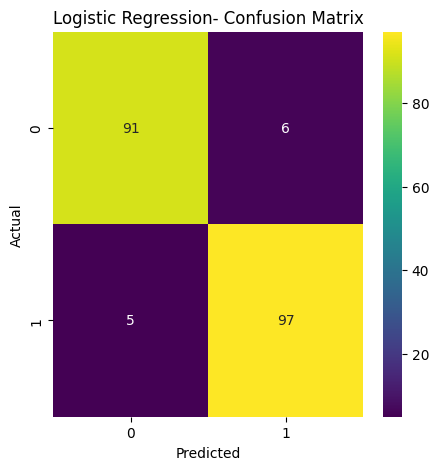

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis")
plt.title("Logistic Regression- Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
##Baseline Model Selection 2
#decision tree
from sklearn.tree import DecisionTreeClassifier
dc=DecisionTreeClassifier(max_depth=7,random_state=42)
dc.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [42]:
y_pred1=dc.predict(X_test)
y_pred1
print("Accuracy Score : ",accuracy_score(y_test, y_pred1))
print("Classification Report : ",classification_report(y_test, y_pred1))

Accuracy Score :  0.9547738693467337
Classification Report :                precision    recall  f1-score   support

           0       0.97      0.94      0.95        97
           1       0.94      0.97      0.96       102

    accuracy                           0.95       199
   macro avg       0.96      0.95      0.95       199
weighted avg       0.96      0.95      0.95       199



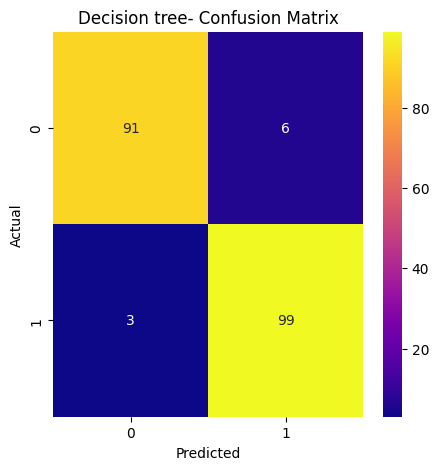

In [24]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred1)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="plasma")
plt.title("Decision tree- Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.9597989949748744
[[93  4]
 [ 4 98]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        97
           1       0.96      0.96      0.96       102

    accuracy                           0.96       199
   macro avg       0.96      0.96      0.96       199
weighted avg       0.96      0.96      0.96       199



In [26]:
#XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9698492462311558
[[94  3]
 [ 3 99]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        97
           1       0.97      0.97      0.97       102

    accuracy                           0.97       199
   macro avg       0.97      0.97      0.97       199
weighted avg       0.97      0.97      0.97       199



In [29]:
#Feature Scaling & Pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(eval_metric="logloss", random_state=42))
])

rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [33]:
#Model Training
import os
import joblib
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

os.makedirs("models", exist_ok=True)

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

xgb_model = XGBClassifier(eval_metric="logloss")
xgb_model.fit(X_train, y_train)

joblib.dump(rf_model, "models/random_forest.pkl")
joblib.dump(xgb_model, "models/xgboost.pkl")
import os
os.listdir("models")


['xgboost.pkl', 'random_forest.pkl']

Random Forest Metrics
Accuracy: 0.9597989949748744
Precision: 0.97
Recall: 0.9509803921568627
F1-score: 0.9603960396039604
ROC-AUC: 0.9961087527794623
[[94  3]
 [ 5 97]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        97
           1       0.97      0.95      0.96       102

    accuracy                           0.96       199
   macro avg       0.96      0.96      0.96       199
weighted avg       0.96      0.96      0.96       199

XGBoost Metrics
Accuracy: 0.964824120603015
Precision: 0.9702970297029703
Recall: 0.9607843137254902
F1-score: 0.9655172413793104
ROC-AUC: 0.9956539316757631
[[94  3]
 [ 4 98]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.96        97
           1       0.97      0.96      0.97       102

    accuracy                           0.96       199
   macro avg       0.96      0.96      0.96       199
weighted avg       0.96      0.96      0.96       199


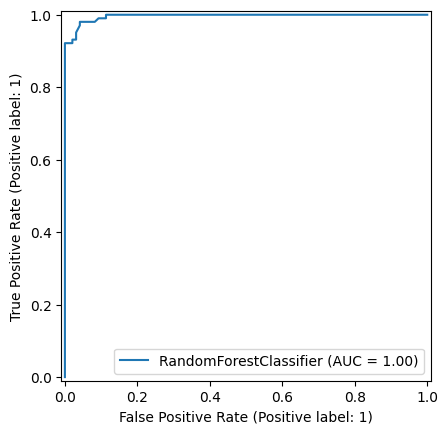

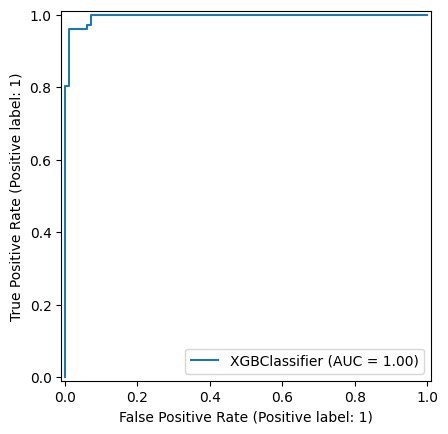

In [32]:
#Model Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

print("Random Forest Metrics")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1-score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


print("XGBoost Metrics")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1-score:", f1_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))

print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))


RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test)

plt.show()

In [35]:
# Hyperparameter tuning for Random Forest using GridSearchCV
from sklearn.model_selection import GridSearchCV

# Parameters to test
rf_params = {
    "n_estimators": [100, 200, 300],   # number of trees in the forest
    "max_depth": [None, 5, 10, 20]     # maximum depth of each tree
}

# Create GridSearch object
rf_grid = GridSearchCV(
    rf_model,         
    rf_params,       
    cv=5,              
    scoring="f1",      
    n_jobs=-1         
)

# Train models with all parameter combinations
rf_grid.fit(X_train, y_train)

# Best Random Forest model after tuning
best_rf = rf_grid.best_estimator_



# Hyperparameter tuning for XGBoost using RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Parameters to test
xgb_params = {
    "n_estimators": [100, 200, 300],   
    "max_depth": [3, 5, 7, 10],       
    "learning_rate": [0.01, 0.05, 0.1, 0.2] 
}

# Create RandomizedSearch object
xgb_random = RandomizedSearchCV(
    xgb_model,    
    xgb_params,       
    n_iter=10,       
    cv=5,             
    scoring="f1",     
    random_state=42,
    n_jobs=-1
)

# Train models with random parameter combinations
xgb_random.fit(X_train, y_train)

# Best XGBoost model after tuning
best_xgb = xgb_random.best_estimator_

In [36]:
from sklearn.metrics import f1_score, recall_score, accuracy_score
import pandas as pd

# Predictions
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# Calculate metrics
rf_f1 = f1_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_acc = accuracy_score(y_test, rf_pred)

xgb_f1 = f1_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

# Model comparison table
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_acc, xgb_acc],
    "Recall": [rf_recall, xgb_recall],
    "F1 Score": [rf_f1, xgb_f1]
})

print(comparison)

# Select best model based on F1-score
best_model = "Random Forest" if rf_f1 > xgb_f1 else "XGBoost"

print("Selected Model:", best_model)

           Model  Accuracy    Recall  F1 Score
0  Random Forest  0.974874  0.980392  0.975610
1        XGBoost  0.964824  0.960784  0.965517
Selected Model: Random Forest


In [45]:
# Generate habitability probabilities
probs = xgb_model.predict_proba(X_test)[:, 1]

# Create results dataframe
results = X_test.copy()
results["Habitability_Score"] = probs
results["Predicted_Class"] = xgb_model.predict(X_test)

# Rank planets by habitability score
results = results.sort_values(by="Habitability_Score", ascending=False)

# Add ranking
results["Rank"] = range(1, len(results) + 1)

# Save output file
import os
os.makedirs("data/processed", exist_ok=True)
results.to_csv("data/processed/habitability_ranked.csv", index=False)

                Feature  Importance
4      Equilibrium_Temp    0.261682
2        Orbital_Period    0.182622
0         Planet_Radius    0.154797
3       Semi_Major_Axis    0.134212
1           Planet_Mass    0.099065
7    Stellar_Luminosity    0.048848
5        Planet_Density    0.047450
6          Stellar_Temp    0.038929
8   Stellar_Metallicity    0.021175
13           StarType_M    0.003729


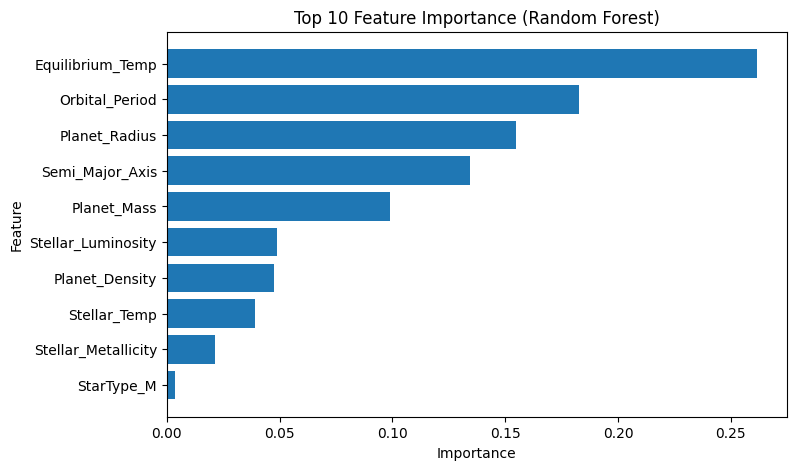

In [38]:
# Feature importance from Random Forest
importances = rf_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

# Plot feature importance
plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"][:10][::-1], importance_df["Importance"][:10][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance (Random Forest)")
plt.show()

In [39]:
# Scientific reasoning behind important features for exoplanet habitability

scientific_reasoning = {
    
    "Planet_Radius": "Earth-sized planets are more likely to retain an atmosphere and support stable surface conditions.",
    
    "Orbital_Distance": "Planets located in the habitable zone receive the right amount of stellar radiation for liquid water.",
    
    "Stellar_Temperature": "Moderate star temperatures provide stable radiation suitable for potential life-supporting environments.",
    
    "Orbital_Stability": "Stable planetary orbits help maintain consistent climate conditions over long periods.",
    
    "Equilibrium_Temperature": "Surface temperature influences the presence of liquid water, which is essential for life."
}

for feature, reason in scientific_reasoning.items():
    print(f"{feature} : {reason}")

Planet_Radius : Earth-sized planets are more likely to retain an atmosphere and support stable surface conditions.
Orbital_Distance : Planets located in the habitable zone receive the right amount of stellar radiation for liquid water.
Stellar_Temperature : Moderate star temperatures provide stable radiation suitable for potential life-supporting environments.
Orbital_Stability : Stable planetary orbits help maintain consistent climate conditions over long periods.
Equilibrium_Temperature : Surface temperature influences the presence of liquid water, which is essential for life.
